In [1]:
# =============================================================================
# Cell 0 (STANDARD): Setup & activate last run
# =============================================================================
import importlib
import numpy as np
import infra
import embeddings
importlib.reload(infra)
importlib.reload(embeddings)

infra.activate_last_run(echo=False)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

SEED = 42
np.random.seed(SEED)

YEAR         = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Figures      :", RP.figures)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)



PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Figures      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# =============================================================================
# Cell 1: Plotting helpers — polar frame and axis utilities
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

GG_GREY = {
    "grey20": "0.2",
    "grey50": "0.5",
    "grey60": "0.6",
    "grey70": "0.7",
    "grey90": "0.9",
    "white":  "1.0",
    "black":  "0.0",
}

def minimal_axes(ax):
    """Remove ticks and spines for a clean polar canvas."""
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

def add_polar_frame(ax,
                    radii=(0.2, 0.4, 0.6, 0.8, 1.0),
                    circle_color="#333333",  circle_lw=0.3,  outer_lw=0.5,
                    spoke_color="#333333",   spoke_lw=0.4,
                    label_color="#333333",   label_fs=9,     label_r=1.06,
                    degree_labels=("0°","45°","90°","135°","180°","225°","270°","315°"),
                    cross_color="#B3B3B3",   cross_lw=0.3,
                    draw_labels=True, draw_spokes=True, draw_cross=True):
    """Draw concentric circles, spokes and degree labels on a Cartesian axis."""
    theta = np.linspace(0, 2 * np.pi, 400)
    for r in radii:
        lw = outer_lw if np.isclose(r, max(radii)) else circle_lw
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                color=circle_color, lw=lw, zorder=1)
    angles = np.arange(0, 2 * np.pi, np.pi / 4)
    if draw_spokes:
        for a in angles:
            ax.plot([0, np.cos(a)], [0, np.sin(a)],
                    color=spoke_color, lw=spoke_lw, zorder=1)
    if draw_labels:
        for a, lab in zip(angles, degree_labels):
            ax.text(label_r * np.cos(a), label_r * np.sin(a), lab,
                    ha="center", va="center", fontsize=label_fs,
                    color=label_color, zorder=2)
    if draw_cross:
        ax.plot([-1, 1], [0, 0], color=cross_color, lw=cross_lw, zorder=1)
        ax.plot([0, 0], [-1, 1], color=cross_color, lw=cross_lw, zorder=1)




In [3]:
# =============================================================================
# Cell 2: Load task and occupation embeddings from current run
# =============================================================================
import pandas as pd
import numpy as np

# Paths from active run
TASK_EMBEDDINGS_PATH = RP.exports / "task_embeddings_polar_scaled.csv"
OCC_EMBEDDINGS_PATH  = RP.exports / "occupation_embeddings_polar_scaled.csv"

shock = pd.read_csv(TASK_EMBEDDINGS_PATH)
jobs  = pd.read_csv(OCC_EMBEDDINGS_PATH)

def ensure_cart(df, name="df"):
    """Add x_cart / y_cart columns from (xi, chi) if not already present."""
    if {"x_cart", "y_cart"}.issubset(df.columns):
        return df
    if {"xi", "chi"}.issubset(df.columns):
        df = df.copy()
        df["xi"]     = pd.to_numeric(df["xi"],  errors="coerce")
        df["chi"]    = pd.to_numeric(df["chi"], errors="coerce")
        df["x_cart"] = df["chi"] * np.cos(df["xi"])
        df["y_cart"] = df["chi"] * np.sin(df["xi"])
        return df
    raise ValueError(
        f"{name} saknar x_cart/y_cart och xi/chi. Finns: {sorted(df.columns)}")

shock = ensure_cart(shock, "shock")
jobs  = ensure_cart(jobs,  "jobs")

print("shock cols:", [c for c in ["xi","chi","x_cart","y_cart"] if c in shock.columns])
print("jobs  cols:", [c for c in ["onet_code","Job Family","xi","chi","x_cart","y_cart"]
                      if c in jobs.columns])




shock cols: ['xi', 'chi', 'x_cart', 'y_cart']
jobs  cols: ['onet_code', 'Job Family', 'xi', 'chi', 'x_cart', 'y_cart']


In [4]:
# =============================================================================
# Cell 3: Load BLS wages and merge onto occupation embeddings
# =============================================================================
import pandas as pd
import numpy as np
 
# Wage file path via PROJECT_ROOT — no hardcoded strings
WAGE_PATH = infra.PROJECT_ROOT / "data" / "wages" / "national_M2023_dl.xlsx"
 
# Columns: 8=OCC_CODE, 9=OCC_TITLE, 10=TOT_EMP, 22=H_MEDIAN
wages = pd.read_excel(WAGE_PATH, usecols=[8, 9, 11, 22]).copy()
wages.columns = ["OCC_CODE", "OCC_TITLE", "TOT_EMP", "H_MEDIAN"]
wages["OCC_CODE"]  = (wages["OCC_CODE"].astype(str)
                      .str.replace(r"\..*", "", regex=True).str.strip())
wages["H_MEDIAN"]  = pd.to_numeric(wages["H_MEDIAN"], errors="coerce")
wages["TOT_EMP"]   = pd.to_numeric(wages["TOT_EMP"],  errors="coerce")
 
# Normalise OCC_CODE in jobs and merge
jobs = jobs.copy()
jobs["OCC_CODE"] = (jobs["onet_code"].astype(str)
                    .str.replace(r"\..*", "", regex=True).str.strip())
jobs = jobs.merge(wages[["OCC_CODE", "TOT_EMP", "H_MEDIAN"]], on="OCC_CODE", how="left")
 
jobs_wage = jobs.dropna(subset=["H_MEDIAN", "x_cart", "y_cart"]).copy()
 
print(f"jobs: {len(jobs):,}  |  jobs_wage (with H_MEDIAN): {len(jobs_wage):,}")
print(f"H_MEDIAN range: ${jobs_wage['H_MEDIAN'].min():.2f} – ${jobs_wage['H_MEDIAN'].max():.2f}")
missing_fam = jobs_wage["Job Family"].isna().sum()
if missing_fam:
    print(f"  Warning: {missing_fam} rows missing Job Family label")
 

jobs: 878  |  jobs_wage (with H_MEDIAN): 785
H_MEDIAN range: $14.02 – $113.46


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/wage_viridis_log10.pdf


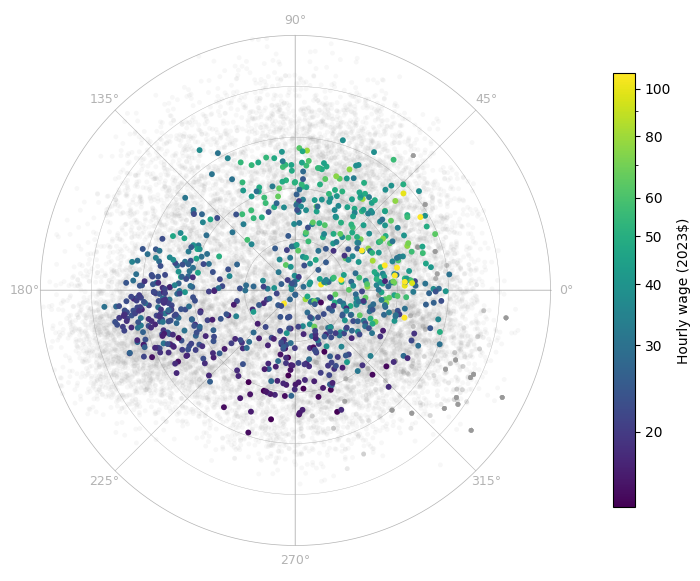

In [5]:
# =============================================================================
# Cell 4: Scatter plot — hourly wages in polar task space (log10 / viridis)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

plt.close("all")

# Validate required columns
for df_name, df_obj, needed in [
    ("jobs_wage", jobs_wage, {"x_cart", "y_cart", "H_MEDIAN"}),
    ("shock",     shock,     {"x_cart", "y_cart"}),
]:
    missing = sorted(needed - set(df_obj.columns))
    if missing:
        raise ValueError(f"{df_name} saknar kolumner: {missing}")

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")

add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
    draw_labels=True, label_fs=9, label_r=1.06,
)

# Background task cloud
ax.scatter(shock["x_cart"], shock["y_cart"],
           s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)

# Wage scatter — log10 normalisation, no clipping
vals      = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos  = vals[np.isfinite(vals) & (vals > 0)]
if vals_pos.size < 10:
    raise ValueError("För få positiva H_MEDIAN-värden för log-skala.")

cap_lo = float(np.nanmin(vals_pos))
cap_hi = float(np.nanpercentile(vals_pos, 99))
norm   = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)

cmap = plt.get_cmap("viridis").copy()
cmap.set_over(cmap(1.0))
cmap.set_under(cmap(0.0))

sc = ax.scatter(jobs_wage["x_cart"], jobs_wage["y_cart"],
                c=vals, cmap=cmap, norm=norm,
                s=18, edgecolors="none", zorder=3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06, extend="neither")
cbar.set_label("Hourly wage (2023$)")
ticks = [t for t in [20, 30, 40, 50, 60, 80, 100] if cap_lo <= t <= cap_hi]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)

# Save to RP.figures
out_fig = RP.figures / "wage_viridis_log10.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()




In [6]:
# =============================================================================
# Cell 5: Aggregate wages per job family — export CSV and display summary
#
# Maps O*NET codes → Job Family via data/onet/All_Job_Families.csv, then
# computes employment-weighted mean, weighted std, median, p25/p75, and
# occupation count per family. Exports to RP.exports and displays inline.
# =============================================================================
import pandas as pd
import numpy as np
from IPython.display import display
 
JOB_FAMILY_PATH = infra.PROJECT_ROOT / "data" / "onet" / "All_Job_Families.csv"
 
# Load mapping: Code -> Job Family
# Kolumnnamnen har inbäddade enkla citattecken: 'Code', 'Job Family'
jf_map = pd.read_csv(JOB_FAMILY_PATH)
jf_map.columns = jf_map.columns.str.strip().str.strip("'")
print("All_Job_Families.csv columns:", list(jf_map.columns))
 
jf_map["_code"]       = jf_map["Code"].astype(str).str.strip()
jf_map["_job_family"] = jf_map["Job Family"].astype(str).str.strip()
 
# Merge onto jobs; use a private column name to avoid collision with any
# existing 'Job Family' column in the occupations file
jw = jobs.copy()
# Drop any pre-existing Job Family column to avoid _x/_y suffixing
if "Job Family" in jw.columns:
    jw = jw.drop(columns=["Job Family"])
jw["_code"] = jw["onet_code"].astype(str).str.strip()
jw = jw.merge(jf_map[["_code", "_job_family"]], on="_code", how="left")
jw = jw.rename(columns={"_job_family": "Job Family"})
 
n_missing = jw["Job Family"].isna().sum()
if n_missing:
    print(f"  Warning: {n_missing}/{len(jw)} occupations could not be mapped "
          f"to a Job Family — they will be excluded from aggregation.")
 
# Keep rows with wage, coordinates and family label
jw = jw.dropna(subset=["H_MEDIAN", "x_cart", "y_cart", "Job Family"]).copy()
 
# Employment weight — TOT_EMP from BLS merge (Cell 3)
jw["_weight"] = pd.to_numeric(jw["TOT_EMP"], errors="coerce").fillna(0.0)
jw.loc[jw["_weight"] <= 0, "_weight"] = 1.0   # fallback for zero/missing rows
 
print(f"\nOccupations used in aggregation: {len(jw):,}")
 
# Weighted statistics helpers
def _wmean(g):
    return float(np.average(g["H_MEDIAN"], weights=g["_weight"]))
 
def _wstd(g):
    mu  = np.average(g["H_MEDIAN"], weights=g["_weight"])
    var = np.average((g["H_MEDIAN"] - mu) ** 2, weights=g["_weight"])
    return float(np.sqrt(var))
 
agg = (
    jw.groupby("Job Family", sort=True)
    .apply(lambda g: pd.Series({
        "wage_mean_weighted": _wmean(g),
        "wage_std_weighted":  _wstd(g),
        "wage_median":        float(g["H_MEDIAN"].median()),
        "wage_p25":           float(g["H_MEDIAN"].quantile(0.25)),
        "wage_p75":           float(g["H_MEDIAN"].quantile(0.75)),
        "n_occupations":      int(len(g)),
        "tot_emp":            float(g["_weight"].sum()),
    }), include_groups=False)
    .reset_index()
    .rename(columns={"Job Family": "job_family"})
    .sort_values("wage_mean_weighted", ascending=False)
    .reset_index(drop=True)
)
 
# Relative wage — normalised to employment-weighted grand mean
# (matches the wage_rel_to_base format expected by gts_core.load_job_families)
grand_mean = float(np.average(agg["wage_mean_weighted"], weights=agg["tot_emp"]))
agg["wage_rel_to_base"] = agg["wage_mean_weighted"] / grand_mean
 
# Export
out_csv = RP.exports / "wage_per_job_family.csv"
agg.to_csv(out_csv, index=False, float_format="%.4f")
print(f"Saved: {out_csv}  ({len(agg)} job families)")
print(f"Grand mean hourly wage: ${grand_mean:.2f}  "
      f"(employment-weighted, TOT_EMP)\n")
 
# Display
display_cols = ["job_family", "wage_mean_weighted", "wage_std_weighted",
                "wage_median", "wage_rel_to_base", "n_occupations"]
display(
    agg[display_cols]
    .style
    .format({
        "wage_mean_weighted": "${:.2f}",
        "wage_std_weighted":  "${:.2f}",
        "wage_median":        "${:.2f}",
        "wage_rel_to_base":   "{:.3f}",
        "n_occupations":      "{:.0f}",
    })
    .bar(subset=["wage_mean_weighted"], color="#4878cf", vmin=0)
    .set_caption("Hourly wages by job family — employment-weighted (TOT_EMP)")
)

All_Job_Families.csv columns: ['Code', 'Occupation', 'Job Family']

Occupations used in aggregation: 785
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/wage_per_job_family.csv  (22 job families)
Grand mean hourly wage: $32.44  (employment-weighted, TOT_EMP)



,job_family,wage_mean_weighted,wage_std_weighted,wage_median,wage_rel_to_base,n_occupations
0,Management,$61.02,$13.97,$56.24,1.881,51
1,Legal,$55.24,$19.69,$34.39,1.703,7
2,Computer and Mathematical,$51.39,$9.97,$50.44,1.584,30
3,Architecture and Engineering,$47.89,$7.04,$47.78,1.476,51
4,Healthcare Practitioners and Technical,$47.41,$22.14,$41.73,1.462,64
5,"Life, Physical, and Social Science",$38.87,$9.17,$39.33,1.198,57
6,Business and Financial Operations,$37.32,$4.05,$36.38,1.151,38
7,"Arts, Design, Entertainment, Sports, and Media",$32.34,$8.15,$30.07,0.997,34
8,Construction and Extraction,$28.51,$5.47,$24.92,0.879,59
9,Protective Service,$28.22,$9.51,$26.24,0.870,25


In [8]:
# =============================================================================
# Cell 6: Load RLE per occupation via onet.education module
#
# Uses the onet-module API (same pattern as onet.build_df_tasks) to read
# "Education, Training, and Experience" and compute frequency-weighted mean
# Required Level of Education (scale 1–12) per O*NET occupation code.
# Requires db from Cell 0 / the active run.
# =============================================================================
import importlib
import onet
import onet.education as edu
importlib.reload(edu)
 
db      = onet.get_db(version=ONET_VERSION)
occ_meta = onet.load_occ_meta(db)
edu_occ  = edu.rle_by_occupation(db)
 
print(f"Occupations with RLE: {len(edu_occ):,}")
print(f"RLE_mean range: {edu_occ['rle_mean'].min():.2f} – {edu_occ['rle_mean'].max():.2f}")
print(edu_occ.head())


Occupations with RLE: 878
RLE_mean range: 1.35 – 11.92
    onet_code  rle_mean  rle_weight_sum
0  11-1011.00    7.2413           100.0
1  11-1011.03    7.7037           100.0
2  11-1021.00    3.6732           100.0
3  11-2011.00    5.2070           100.0
4  11-2021.00    6.6805           100.0


In [9]:
# =============================================================================
# Cell 7: Merge RLE onto occupation embeddings
#
# Reads occupation embeddings fresh from RP.exports and joins rle_mean
# from Cell 6. Independent of the wage merge in Cell 3.
# =============================================================================
import pandas as pd
import numpy as np
 
jobs_edu = pd.read_csv(RP.exports / "occupation_embeddings_polar_scaled.csv")
jobs_edu = ensure_cart(jobs_edu, "jobs_edu")
jobs_edu = jobs_edu.merge(edu_occ[["onet_code", "rle_mean"]], on="onet_code", how="left")
 
n_missing = jobs_edu["rle_mean"].isna().sum()
print(f"jobs_edu: {len(jobs_edu):,}  |  with rle_mean: {jobs_edu['rle_mean'].notna().sum():,}"
      + (f"  |  missing: {n_missing}" if n_missing else ""))
 
 


jobs_edu: 878  |  with rle_mean: 878


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/education_rle_mean.pdf


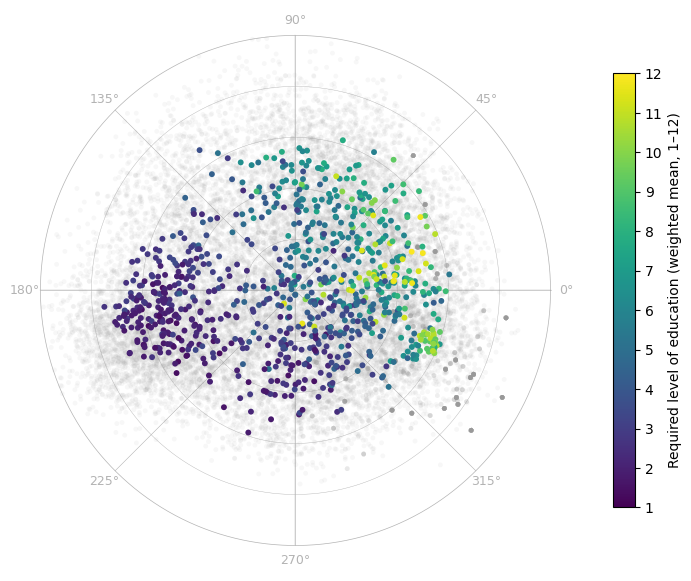

In [10]:
# =============================================================================
# Cell 9: Scatter plot — Required Level of Education in polar task space
#
# Linear colour scale 1–12 (viridis), consistent palette with wage figure.
# Saved to RP.figures.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
 
plt.close("all")
 
for df_name, df_obj, needed in [
    ("jobs_edu", jobs_edu, {"x_cart", "y_cart", "rle_mean"}),
    ("shock",    shock,    {"x_cart", "y_cart"}),
]:
    miss = sorted(needed - set(df_obj.columns))
    if miss:
        raise ValueError(f"{df_name} saknar kolumner: {miss}")
 
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")
 
add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
    draw_labels=True, label_fs=9, label_r=1.06,
)
ax.scatter(shock["x_cart"], shock["y_cart"],
           s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)
 
vals = np.asarray(jobs_edu["rle_mean"], float)
mask = np.isfinite(vals)
norm = mcolors.Normalize(vmin=1, vmax=12, clip=False)
cmap = plt.get_cmap("viridis").copy()
 
sc = ax.scatter(jobs_edu.loc[mask, "x_cart"], jobs_edu.loc[mask, "y_cart"],
                c=vals[mask], cmap=cmap, norm=norm,
                s=18, edgecolors="none", zorder=3)
 
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)
 
cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06)
cbar.set_label("Required level of education (weighted mean, 1–12)")
cbar.set_ticks(list(range(1, 13)))
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)
 
out_fig = RP.figures / "education_rle_mean.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()
 
 


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/panel_wage_education.pdf


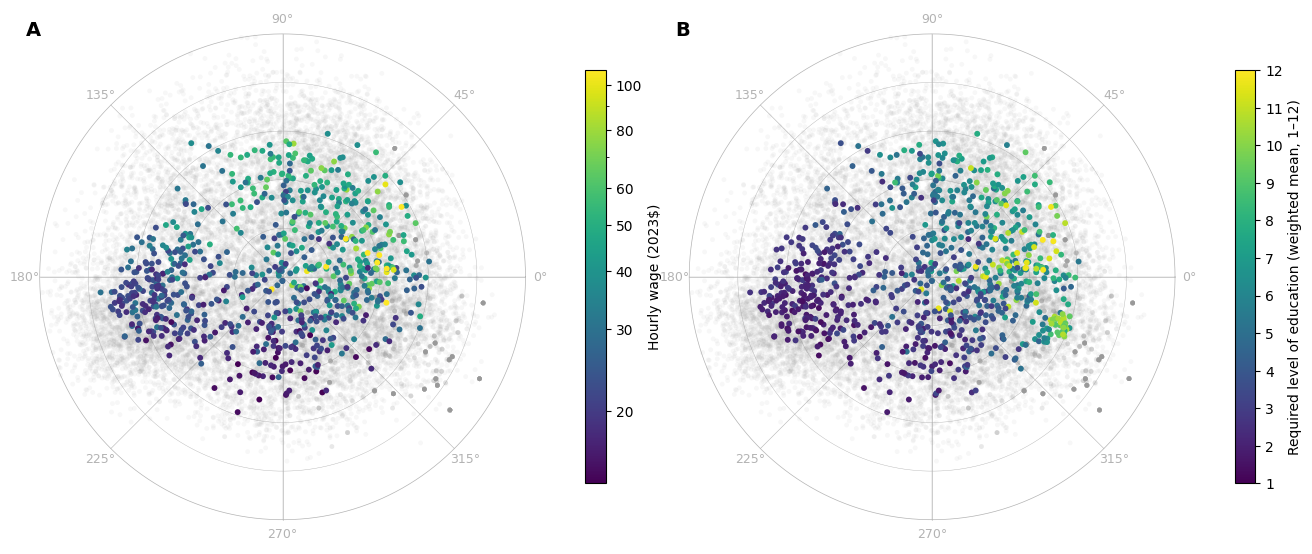

In [11]:
# =============================================================================
# Cell 10: Two-panel figure — wage (A) and education (B) side by side
#
# Combines the single-panel figures into one publication-ready panel figure.
# Saved to RP.figures.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
 
plt.close("all")
 
for df_name, df_obj, needed in [
    ("jobs_wage", jobs_wage, {"x_cart", "y_cart", "H_MEDIAN"}),
    ("jobs_edu",  jobs_edu,  {"x_cart", "y_cart", "rle_mean"}),
    ("shock",     shock,     {"x_cart", "y_cart"}),
]:
    miss = sorted(needed - set(df_obj.columns))
    if miss:
        raise ValueError(f"{df_name} saknar kolumner: {miss}")
 
def base_polar(ax):
    """Apply shared polar frame and background task cloud."""
    add_polar_frame(
        ax,
        circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
        label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
        draw_labels=True, label_fs=9, label_r=1.06,
    )
    ax.scatter(shock["x_cart"], shock["y_cart"],
               s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    minimal_axes(ax)
 
fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")
 
# Panel A: wage (log scale)
base_polar(axA)
vals_w   = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos = vals_w[np.isfinite(vals_w) & (vals_w > 0)]
cap_lo   = float(np.nanmin(vals_pos))
cap_hi   = float(np.nanpercentile(vals_pos, 99))
norm_w   = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)
cmap_w   = plt.get_cmap("viridis").copy()
cmap_w.set_over(cmap_w(1.0)); cmap_w.set_under(cmap_w(0.0))
 
scA = axA.scatter(jobs_wage["x_cart"], jobs_wage["y_cart"],
                  c=vals_w, cmap=cmap_w, norm=norm_w,
                  s=18, edgecolors="none", zorder=3)
cbarA = fig.colorbar(scA, ax=axA, fraction=0.035, pad=0.06, extend="neither")
cbarA.set_label("Hourly wage (2023$)")
ticksA = [t for t in [20, 30, 40, 50, 60, 80, 100] if cap_lo <= t <= cap_hi]
cbarA.set_ticks(ticksA)
cbarA.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
cbarA.ax.yaxis.get_offset_text().set_visible(False)
axA.text(0.02, 0.98, "A", transform=axA.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
# Panel B: education (linear 1–12)
base_polar(axB)
vals_e = np.asarray(jobs_edu["rle_mean"], float)
mask_e = np.isfinite(vals_e)
norm_e = mcolors.Normalize(vmin=1, vmax=12, clip=False)
cmap_e = plt.get_cmap("viridis").copy()
 
scB = axB.scatter(jobs_edu.loc[mask_e, "x_cart"], jobs_edu.loc[mask_e, "y_cart"],
                  c=vals_e[mask_e], cmap=cmap_e, norm=norm_e,
                  s=18, edgecolors="none", zorder=3)
cbarB = fig.colorbar(scB, ax=axB, fraction=0.035, pad=0.06)
cbarB.set_label("Required level of education (weighted mean, 1–12)")
cbarB.set_ticks(list(range(1, 13)))
cbarB.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
cbarB.ax.yaxis.get_offset_text().set_visible(False)
axB.text(0.02, 0.98, "B", transform=axB.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
fig.subplots_adjust(wspace=0.10)
out_fig = RP.figures / "panel_wage_education.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()
 
 


In [12]:
# =============================================================================
# Cell 11: Aggregate RLE per job family — export rle_by_job_family.csv
#
# Uses edu.rle_by_job_family() with occ_meta (contains Job Family + TOT_EMP)
# to compute employment-weighted mean RLE per family. Exports to RP.exports
# in the format expected by gts_core.init(): columns Job Family, rle_mean_family.
# =============================================================================
import pandas as pd
 
# occ_meta needs Job Family — merge from jf_map if not already present
_occ = occ_meta.copy()
_occ["_code"] = _occ["onet_code"].astype(str).str.strip()
if "Job Family" not in _occ.columns:
    _occ = _occ.merge(
        jf_map[["_code", "_job_family"]].rename(columns={"_job_family": "Job Family"}),
        on="_code", how="left")
 
# Attach TOT_EMP from wages for employment weighting
if "TOT_EMP" not in _occ.columns and "TOT_EMP" in wages.columns:
    _occ["OCC_CODE"] = _occ["onet_code"].astype(str).str.replace(r"\..*", "", regex=True).str.strip()
    _occ = _occ.merge(wages[["OCC_CODE", "TOT_EMP"]], on="OCC_CODE", how="left")
 
rle_agg = edu.rle_by_job_family(db, _occ, weight_col="TOT_EMP")
 
out_csv = RP.exports / "rle_by_job_family.csv"
rle_agg.to_csv(out_csv, index=False, float_format="%.4f")
print(f"Saved: {out_csv}  ({len(rle_agg)} job families, employment-weighted)")
print(f"RLE range: {rle_agg['rle_mean_family'].min():.2f} – "
      f"{rle_agg['rle_mean_family'].max():.2f}\n")
 
display(
    rle_agg
    .style
    .format({
        "rle_mean_family": "{:.2f}",
        "rle_std_family":  "{:.2f}",
        "n_occupations":   "{:.0f}",
    })
    .bar(subset=["rle_mean_family"], color="#4878cf", vmin=0)
    .set_caption("Required Level of Education by job family — employment-weighted (TOT_EMP)")
)

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/rle_by_job_family.csv  (22 job families, employment-weighted)
RLE range: 1.96 – 8.85



,Job Family,rle_mean_family,rle_std_family,n_occupations
0,Legal,8.85,2.65,7
1,"Life, Physical, and Social Science",7.44,2.03,57
2,Healthcare Practitioners and Technical,7.10,2.12,82
3,Educational Instruction and Library,6.63,1.54,61
4,Community and Social Service,6.49,0.85,14
5,Architecture and Engineering,6.24,1.06,51
6,Computer and Mathematical,5.69,0.75,30
7,Business and Financial Operations,5.66,0.88,43
8,Management,5.43,1.36,52
9,"Arts, Design, Entertainment, Sports, and Media",5.18,1.00,37


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/correlation_education_wage.pdf


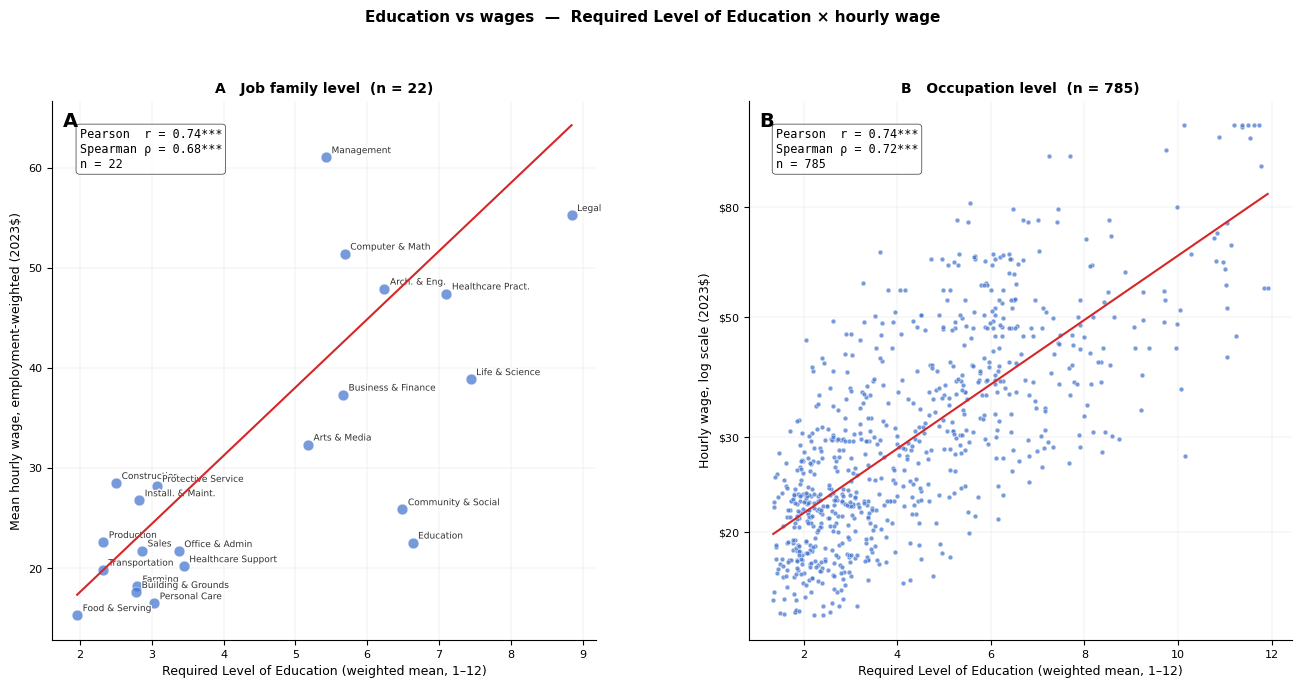

In [13]:
# =============================================================================
# Cell 12: Correlation — Required Level of Education vs hourly wage
#
# Two-panel scatter with OLS regression line and Pearson/Spearman coefficients.
# Panel A: per job family (22 points, labelled, employment-weighted regression).
# Panel B: per occupation (~800 points, density-shaded).
# Saved to RP.figures.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
from gts_plot import SHORT
 
plt.close("all")
 
# ── Build per-family dataset ──────────────────────────────────────────────────
fam_corr = agg.merge(
    rle_agg[["Job Family", "rle_mean_family"]],
    left_on="job_family", right_on="Job Family", how="inner"
).dropna(subset=["wage_mean_weighted", "rle_mean_family"])
 
# ── Build per-occupation dataset ──────────────────────────────────────────────
occ_corr = jobs_wage.merge(
    edu_occ[["onet_code", "rle_mean"]], on="onet_code", how="inner"
).dropna(subset=["H_MEDIAN", "rle_mean"])
 
# ── Helper: annotated scatter panel ──────────────────────────────────────────
def _scatter_panel(ax, x, y, weights=None, labels=None,
                   xlabel="", ylabel="", title="",
                   xlog=False, ylog=False, point_color="#4878cf"):
    """Scatter + WLS regression line + Pearson & Spearman annotations."""
    xi = np.log10(x) if xlog else np.array(x, float)
    yi = np.log10(y) if ylog else np.array(y, float)
    mask = np.isfinite(xi) & np.isfinite(yi)
    xi, yi = xi[mask], yi[mask]
    w = np.array(weights, float)[mask] if weights is not None else np.ones(len(xi))
 
    # Scatter
    ax.scatter(x[mask] if not xlog else xi,
               y[mask] if not ylog else yi,
               s=60 if labels is not None else 12,
               c=point_color, alpha=0.75, edgecolors="white",
               linewidths=0.4, zorder=3)
 
    # WLS regression line
    coeffs = np.polyfit(xi, yi, 1, w=w)
    x_line = np.linspace(xi.min(), xi.max(), 200)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color="#d62728", lw=1.5, zorder=4)
 
    # Pearson + Spearman on log-transformed values
    r_p, p_p = stats.pearsonr(xi, yi)
    r_s, p_s = stats.spearmanr(xi, yi)
 
    def _sig(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""
 
    ax.text(0.05, 0.95,
            f"Pearson  r = {r_p:.2f}{_sig(p_p)}\n"
            f"Spearman ρ = {r_s:.2f}{_sig(p_s)}\n"
            f"n = {mask.sum()}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=8.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, lw=0.5))
 
    # Labels (job family panel)
    if labels is not None:
        labs = np.array(labels)[mask]
        xp = xi if xlog else np.array(x, float)[mask]
        yp = yi if ylog else np.array(y, float)[mask]
        for lx, ly, lab in zip(xp, yp, labs):
            ax.annotate(
                SHORT.get(lab, lab), (lx, ly),
                fontsize=6.5, color="#333333",
                xytext=(4, 3), textcoords="offset points",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])
 
    # Axis formatting
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.grid(True, lw=0.3, alpha=0.4)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
 
 
# ── Figure ────────────────────────────────────────────────────────────────────
fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")
 
# Panel A: job family
_scatter_panel(
    axA,
    x       = fam_corr["rle_mean_family"].values,
    y       = fam_corr["wage_mean_weighted"].values,
    weights = fam_corr["tot_emp"].values,
    labels  = fam_corr["job_family"].values,
    xlabel  = "Required Level of Education (weighted mean, 1–12)",
    ylabel  = "Mean hourly wage, employment-weighted (2023$)",
    title   = "A   Job family level  (n = 22)",
    ylog    = False,
)
axA.text(0.02, 0.98, "A", transform=axA.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
# Panel B: occupation (log wage y-axis for readability)
_scatter_panel(
    axB,
    x       = occ_corr["rle_mean"].values,
    y       = occ_corr["H_MEDIAN"].values,
    xlabel  = "Required Level of Education (weighted mean, 1–12)",
    ylabel  = "Hourly wage, log scale (2023$)",
    title   = f"B   Occupation level  (n = {len(occ_corr):,})",
    ylog    = True,
    point_color = "#4878cf",
)
# Relabel y-axis ticks back to dollar values
yticks = [10, 20, 30, 50, 80, 120]
axB.set_yticks([np.log10(t) for t in yticks if occ_corr["H_MEDIAN"].min() <= t <= occ_corr["H_MEDIAN"].max()])
axB.set_yticklabels([f"${t}" for t in yticks if occ_corr["H_MEDIAN"].min() <= t <= occ_corr["H_MEDIAN"].max()])
axB.text(0.02, 0.98, "B", transform=axB.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
fig.suptitle("Education vs wages  —  Required Level of Education × hourly wage",
             fontsize=11, fontweight="bold", y=1.01)
fig.subplots_adjust(wspace=0.28)
 
out_fig = RP.figures / "correlation_education_wage.pdf"
fig.savefig(out_fig, dpi=300, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()

In [14]:
print(jw[["onet_code", "TOT_EMP", "_weight"]].head(10).to_string())
print("TOT_EMP dtype:", jw["TOT_EMP"].dtype)
print("max TOT_EMP:", jw["TOT_EMP"].max())

    onet_code    TOT_EMP    _weight
0  11-1011.00   211230.0   211230.0
1  11-1011.03   211230.0   211230.0
2  11-1021.00  3507810.0  3507810.0
3  11-2011.00    20630.0    20630.0
4  11-2021.00   368940.0   368940.0
5  11-2022.00   575880.0   575880.0
6  11-2033.00    31810.0    31810.0
7  11-3012.00   242520.0   242520.0
8  11-3013.00   131400.0   131400.0
9  11-3013.01   131400.0   131400.0
TOT_EMP dtype: float64
max TOT_EMP: 3684740.0
